# Analiza i predikcija baznog indeksa potrošačkih cena u Srbiji

Cilj ovog projekta je analiza i predikcija kretanja cena u Srbiji korišćenjem vremenskih serija. Fokus je na baznom indeksu potrošačkih cena (prosečan nivo cena iz 2006. godine = 100), koji omogućava sagledavanje dugoročnog kumulativnog rasta troškova života.

Metodološki pristup:
U radu se koristi SARIMA model. S obzirom na to da bazni indeksi pokazuju snažan trend i promenu varijanse kroz vreme, primenjene su sledeće tehnike:

Logaritamska transformacija: Za stabilizaciju varijanse i prelazak sa multiplikativnog na aditivni model.

Dekompozicija serije: Razdvajanje na trend, sezonalnost i reziduale.

Analiza stacionarnosti: Korišćenje ADF (Augmented Dickey-Fuller) testa radi provere potrebe za diferenciranjem.

O inflaciji:
Inflacija predstavlja opšti porast nivoa cena ili pad kupovne moći novca. Praćenje baznog indeksa (umesto samo mesečnih stopa promene) ključno je za razumevanje ukupne ekonomske stabilnosti i planiranje monetarne politike, kao što je prilagođavanje kamatnih stopa radi obuzdavanja prebrzog rasta cena.


In [287]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

full_data_raw = pd.read_csv('data/inflacija.csv', sep=';')

temp_data = full_data_raw[full_data_raw['skrIndikator'].str.contains('Bazni', na=False)].copy()

meseci_map = {
    'januar': '01', 'februar': '02', 'mart': '03', 'april': '04', 
    'maj': '05', 'jun': '06', 'jul': '07', 'avgust': '08', 
    'septembar': '09', 'oktobar': '10', 'novembar': '11', 'decembar': '12'
}

def konvertuj(tekst):
    try:
        godina, mesec = str(tekst).split('/')
        return f"{godina}-{meseci_map[mesec.lower()]}-01"
    except:
        return None

temp_data['nVrTacka'] = temp_data['nVrTacka'].apply(konvertuj)
temp_data['nVrTacka'] = pd.to_datetime(temp_data['nVrTacka'])


temp_data['Vrednost'] = pd.to_numeric(temp_data['Vrednost'], errors='coerce')
temp_data = temp_data[['nVrTacka', 'Vrednost']].dropna().sort_values('nVrTacka').set_index('nVrTacka')

temp_data['Inflacija'] = temp_data['Vrednost']
temp_data = temp_data.asfreq('MS')

split_point = int(len(temp_data) * 0.8)
df = temp_data.iloc[:split_point].copy() 
test_df = temp_data.iloc[split_point:].copy()

df['Inflacija_log'] = np.log(df['Inflacija'])
test_df['Inflacija_log'] = np.log(test_df['Inflacija'])

print(f"Učitano {len(temp_data)} meseci. Poslednja vrednost: {temp_data['Inflacija'].iloc[-1]}")

Učitano 228 meseci. Poslednja vrednost: 288.0


In [288]:
print(temp_data.head())
print(temp_data.tail())
print(temp_data.describe())

            Vrednost  Inflacija
nVrTacka                       
2007-01-01     102.2      102.2
2007-02-01     101.9      101.9
2007-03-01     102.5      102.5
2007-04-01     103.2      103.2
2007-05-01     105.1      105.1
            Vrednost  Inflacija
nVrTacka                       
2025-08-01     290.2      290.2
2025-09-01     285.6      285.6
2025-10-01     287.0      287.0
2025-11-01     287.7      287.7
2025-12-01     288.0      288.0
         Vrednost   Inflacija
count  228.000000  228.000000
mean   188.692982  188.692982
std     49.022970   49.022970
min    101.900000  101.900000
25%    154.225000  154.225000
50%    184.350000  184.350000
75%    204.825000  204.825000
max    290.200000  290.200000


### Metodologija i transformacija podataka:

U ovom projektu korišćeni su bazni indeksi potrošačkih cena, gde vrednost 100 predstavlja prosečan nivo cena iz referentne 2006. godine. Za razliku od lančanih indeksa, bazni indeksi omogućavaju praćenje kumulativnog porasta cena kroz čitav posmatrani period.

## Vizualizacija podataka

Na grafiku je prikazana mesečna inflacija. Može se uočiti rastući trend i potencijalna sezonalnost.

##### Identifikacija prirode serije:
Vizuelnom inspekcijom originalnih podataka uočava se da se amplituda sezonskih oscilacija povećava srazmerno sa porastom nivoa baznog indeksa. Ovo ukazuje na multiplikativni karakter vremenske serije.

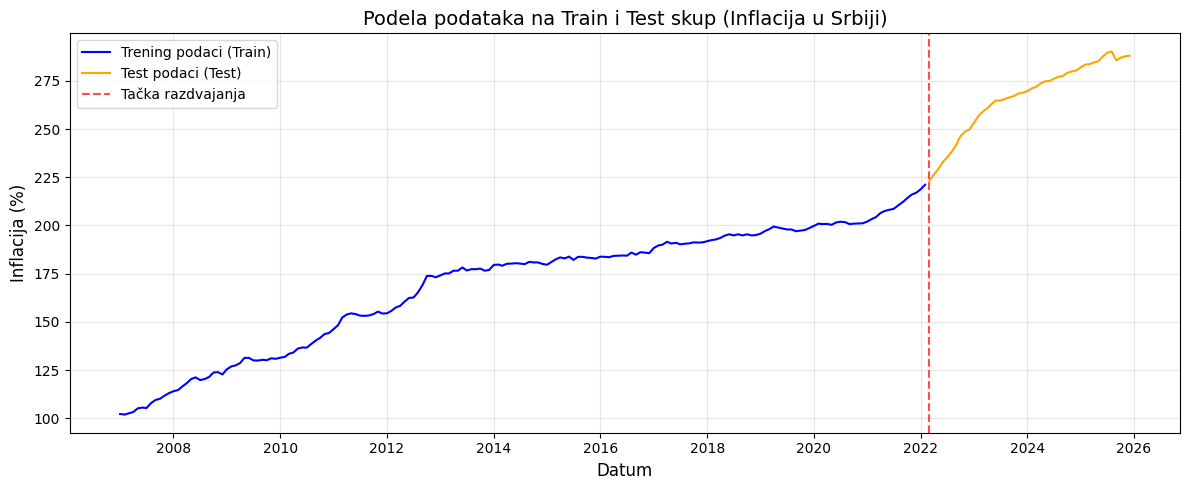

In [289]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Inflacija'], label='Trening podaci (Train)', color='blue', linewidth=1.5)
plt.plot(test_df.index, test_df['Inflacija'], label='Test podaci (Test)', color='orange', linewidth=1.5)
plt.axvline(x=test_df.index[0], color='red', linestyle='--', alpha=0.7, label='Tačka razdvajanja')

plt.title('Podela podataka na Train i Test skup (Inflacija u Srbiji)', fontsize=14)
plt.xlabel('Datum', fontsize=12)
plt.ylabel('Inflacija (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

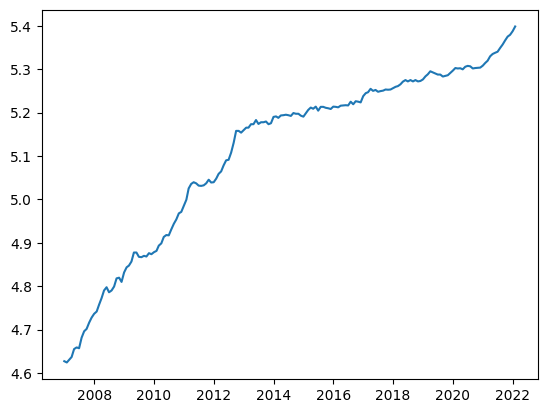

In [290]:
stationary_data_log = df['Inflacija_log'].copy() # duboka kopija da ne menjamo kolonu
plt.plot(stationary_data_log);


Logaritmovanjem smo dobili nove podatke tako da magnituda sezonalnosti, cikličnosti i šuma ne zavisi od trenda ➡️ dobili smo aditivni model. 
Sada primenjujemo STL metod da vremensku seriju razdvojimo na komponente:

## Dekompozicija serije

STL dekompozicija razdvaja seriju na:
- trend
- sezonalnost
- rezidual
- šum

Ovo pomaže da bolje razumemo strukturu podataka.

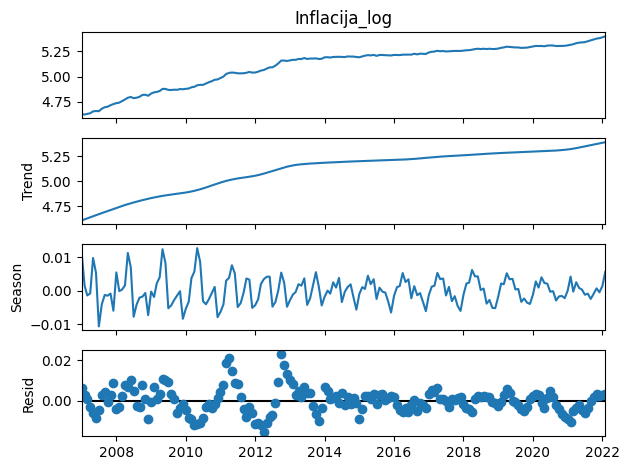

In [291]:
from statsmodels.tsa.seasonal import STL
stl = STL(df['Inflacija_log']).fit()
stl.plot()
plt.show()

Tumačenje: Primenom STL metode rastavili smo vremensku seriju na komponente i vidimo da u podacima postoji trend i sezonalnost. 

## Test stacionarnosti (ADF test)

Za testiranje stacionarnosti koristimo ADF test (*Augmented Dickey–Fuller*). Sa 95% tačnosti (p-vrednost ≤ 0.05) tvrdimo da je vremenska serija stacionarna kada je ADF ≤ -2.862. Umesto ADF vrednosti možemo koristiti p-vrednost. Ako je konkretna `p-vrednost ≤ 0.05` => 95% smo sigurni da je vremenska serija stacionarna.

Ako je p-vrednost manja od 0.05, serija je stacionarna. U suprotnom, potrebno je diferenciranje.

U našem slučaju p vrednost je veca od 0.05 zbog toga se odlucujemo na diferenciranje.


adf_value=-1.98, p_value=0.30
ne postoji stacionarnost


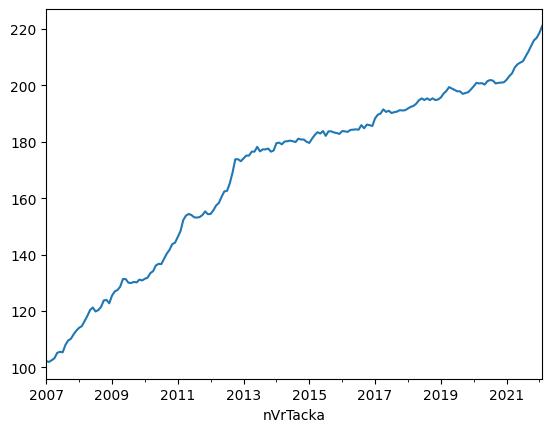

In [292]:
df['Inflacija'].plot();
from statsmodels.tsa.stattools import adfuller
adf_value = adfuller(df['Inflacija'])[0] 
p_value = adfuller(df['Inflacija'])[1]
print(f'{adf_value=:.2f}, {p_value=:.2f}')

if p_value <= 0.05: print('postoji stacionarnost')
else: print('ne postoji stacionarnost')

p_value=0.00
postoji stacionarnost


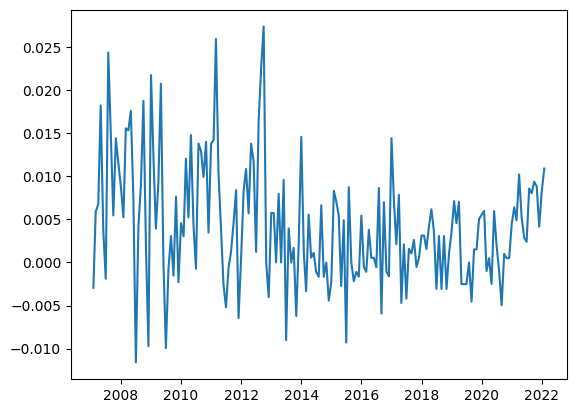

In [293]:
stationary_data = df['Inflacija_log'].diff().dropna()
p_value = adfuller(stationary_data)[1]
print(f'{p_value=:.2f}')
if p_value <= 0.05: print('postoji stacionarnost')
else: print('ne postoji stacionarnost')
plt.plot(stationary_data);

### Ljung–Box Q test
Koristimo ga da bismo utvrdili da li postoji autokorelacija u podacima.
Hipoteze testa su:

- H₀ (nulta hipoteza): Nema autokorelacije do određenog reda h.
- H₁ (alternativna): Postoji autokorelacija barem na nekom od prvih h lagova.

Do zaključaka da li autokorelacija reda h postoji ili ne dolazimo posmatrajući p vrednost:
- Ako je p-vrednost > 0.05, ne odbacujemo H₀ → nema značajne autokorelacije.
- Ako je p-vrednost < 0.05, odbacujemo H₀ → postoji autokorelacija.

In [294]:
result = acorr_ljungbox(stationary_data, lags=15, return_df=True)
result

,lb_stat,lb_pvalue
1,13.976040,1.851552e-04
2,15.820838,3.669008e-04
3,19.357804,2.305600e-04
4,28.751086,8.782363e-06
5,33.092774,3.607117e-06
6,34.640630,5.058370e-06
7,38.033372,2.986228e-06
8,39.363241,4.208392e-06
9,39.940552,7.789296e-06
10,40.039323,1.667669e-05


Kolona <b>lb_pvalue</b> prikazuje p vrednost za svaki od 15 lag-ova (prethodnih 1, 2..., 15 meseci). Sve vrednosti su <b>ispod 0.05</b>, pa zaključujemo da <b>postoji autokorelacija</b> za svaki od lag-ova, odnosno, treba dodatno proveriti sve opsege vrednosti na <b>autokorelogramu</b>, kako bi se zaključilo koji raspon meseci nam može značiti prilikom proširivanja skupa podataka novim kolonama.

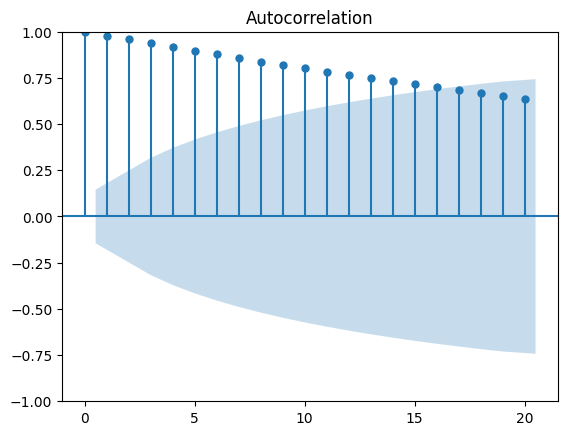

In [295]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['Inflacija'], lags=20)
plt.show()

Tumačenje: Sa grafika autokorelacije (ACF) vidimo da nakon $k=16$ vrednosti postaju statistički beznačajne (ulaze u osenčenu zonu poverenja). Visoka vrednost ACF-a za lag $k=2$ ukazuje na snažan uticaj nivoa cena od pre dva meseca na trenutnu vrednost.

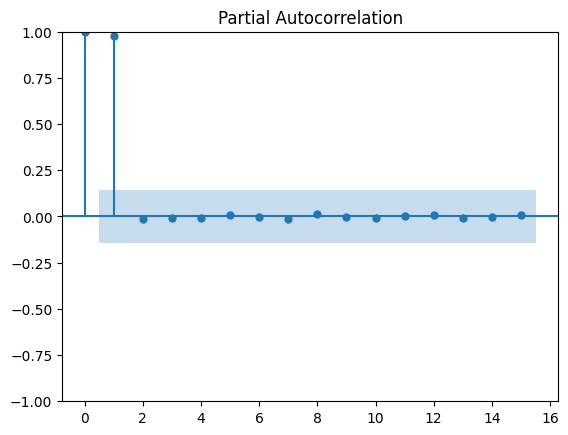

In [296]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Inflacija'], lags=15)
plt.show()

Parcijalna autokorelacija

Autokorelacija meri direktan i indirektan uticaj, dok parcijalna autokorelacija meri samo direktan uticaj (eng. *partial autocorrelation function - PACF*). Da izmerimo samo direktan uticaj koristimo *PACF*.

Tumačenje: Na grafiku parcijalne autokorelacije (PACF) uočavamo direktan uticaj na formiranje cene u tekućem mesecu:Lag $k=1$: Ekstremno visoka vrednost potvrđuje dominantan direktni uticaj cena iz prethodnog meseca.

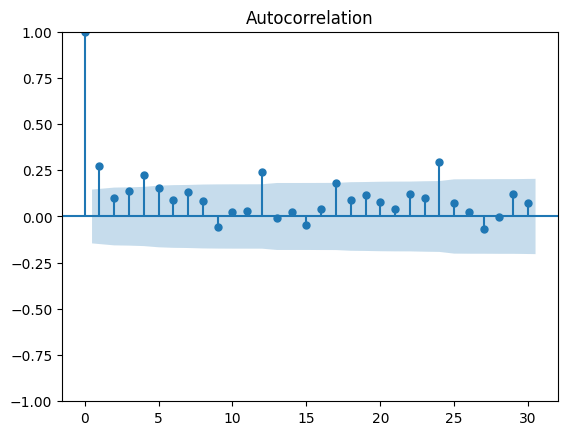

In [297]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(stationary_data, lags=30)
plt.show()

Parametar q (red MA komponente) određen je analizom ACF funkcije. Uočeni su statistički značajni koeficijenti autokorelacije na prva dva laga. Uzimao q=1.

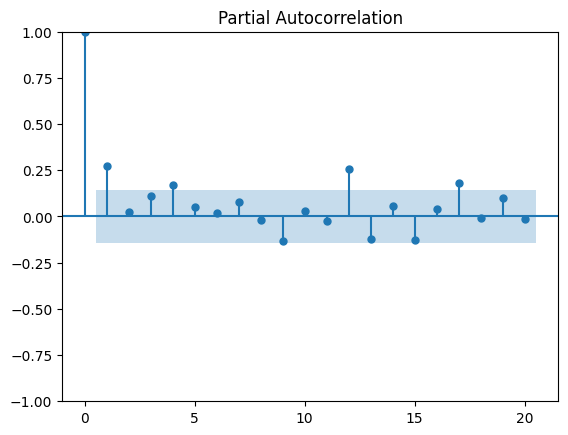

In [298]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(stationary_data, lags=20)
plt.show()

Za p-vrednost mozemo uzeti p=1.


## SARIMA model

Na osnovu prethodne analize, primenjen je ARIMAX model za predikciju inflacije.

Model uzima u obzir i sezonalnost i trend u podacima.

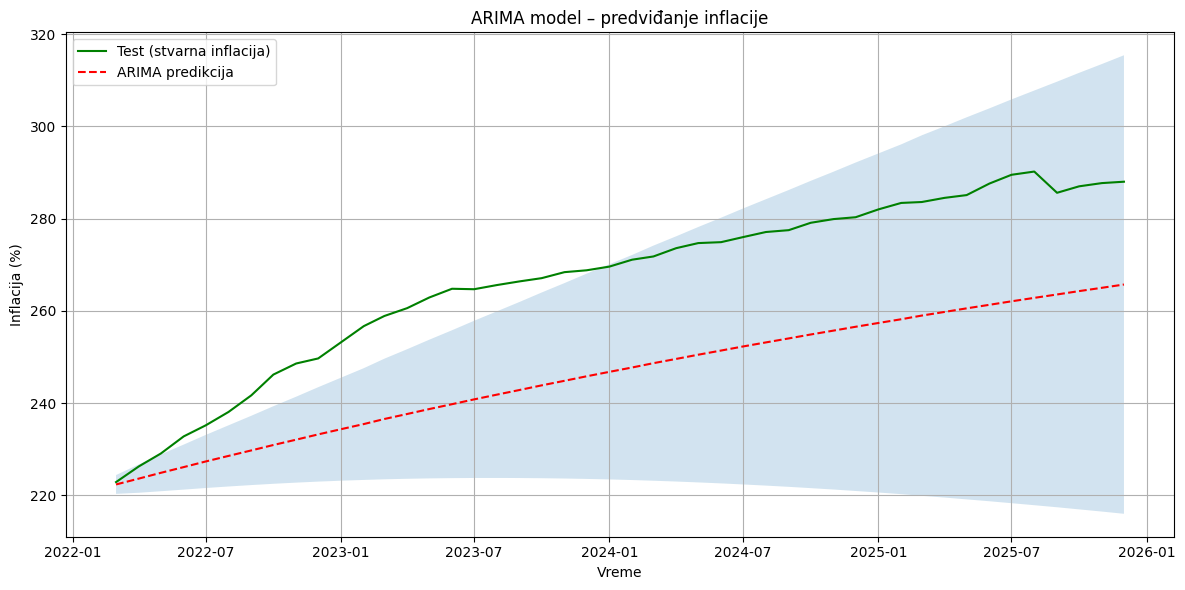

In [299]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

model = sm.tsa.ARIMA(
    df['Inflacija'],
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

forecast = results.get_forecast(steps=len(test_df))
pred = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12,6))
plt.plot(test_df.index, test_df['Inflacija'], label='Test (stvarna inflacija)', color='green')
plt.plot(test_df.index, pred, label='ARIMA predikcija', color='red', linestyle='--')

plt.fill_between(test_df.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.2)

plt.title('ARIMA model – predviđanje inflacije')
plt.xlabel('Vreme')
plt.ylabel('Inflacija (%)')
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

## Evaluacija modela

Model je evaluiran pomoću:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

Manje vrednosti znače bolju preciznost modela.



In [300]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_df['Inflacija'], pred)
rmse = np.sqrt(mean_squared_error(test_df['Inflacija'], pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 20.56
RMSE: 21.61


Logika drift modela: Ako je inflacija u proseku rasla 0.5% mesečno u prošlosti, rašće tako i u test periodu.

In [311]:
# Izračunavanje prosečnog mesečnog prirasta (drifta) u trening skupu
n = len(df)
prva_vrednost = df['Inflacija'].iloc[0]
poslednja_vrednost = df['Inflacija'].iloc[-1]

drift = (poslednja_vrednost - prva_vrednost) / (n - 1)

# Predikcija: Poslednja tačka + (korak * drift)
drift_predictions = [poslednja_vrednost + (h * drift) for h in range(1, len(test_df) + 1)]

mae_drift = mean_absolute_error(test_df['Inflacija'], drift_predictions)
rmse_drift = np.sqrt(mean_squared_error(test_df['Inflacija'], drift_predictions))

print(f"MAE: {mae_drift:.2f}")
print(f"RMSE: {rmse_drift:.2f}")


MAE: 30.17
RMSE: 31.92


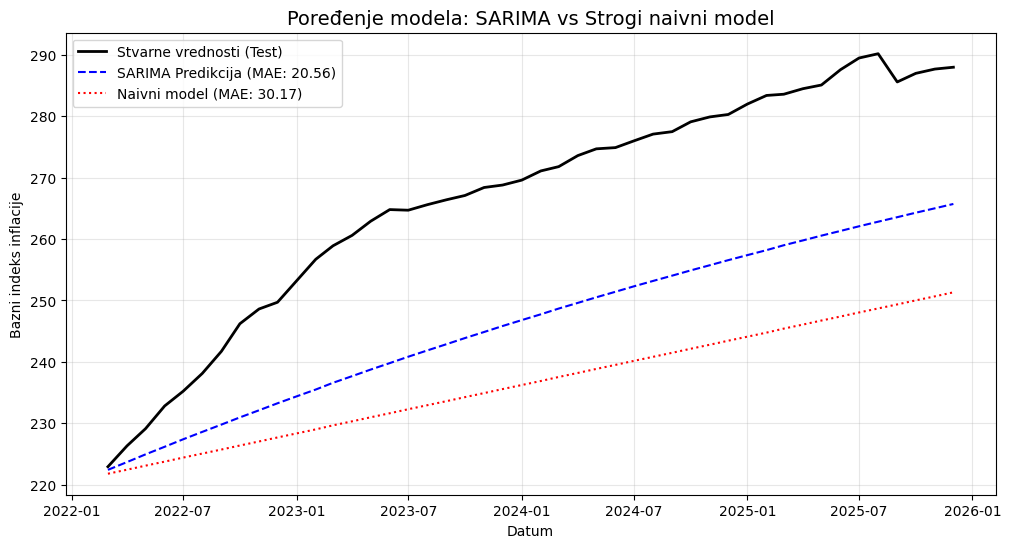

In [308]:
plt.figure(figsize=(12, 6))
plt.plot(test_df.index, test_df['Inflacija'], label='Stvarne vrednosti (Test)', color='black', linewidth=2)
plt.plot(test_df.index, pred, label=f'SARIMA Predikcija (MAE: {mae:.2f})', color='blue', linestyle='--')
plt.plot(test_df.index, drift_predictions, label=f'Naivni model (MAE: {mae_drift:.2f})', color='red', linestyle=':')

plt.title('Poređenje modela: SARIMA vs Strogi naivni model', fontsize=14)
plt.xlabel('Datum')
plt.ylabel('Bazni indeks inflacije')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Zaključak

Iako SARIMA model pokazuje znatno bolju preciznost u odnosu na drift model (smanjenje MAE sa 30.17 na 20.56), primetno je da model zasnovan isključivo na istorijskim vrednostima same inflacije ima svoja ograničenja. Za postizanje veće preciznosti i robusnosti u predviđanju, u budućim istraživanjima bi trebalo razmotriti prelazak sa SARIMA na SARIMAX model, koji omogućava uvođenje eksternih faktora (egzogenih varijabli).

Ključni faktori za uvođenje u model:
Devizni kurs (EUR/RSD): S obzirom na visoku evroizaciju privrede u Srbiji, promene u kursu direktno utiču na cene uvozne robe, a samim tim i na bazni indeks potrošačkih cena.

Referentna kamatna stopa (NBS): Monetarna politika je glavni instrument za kontrolu inflacije. Uključivanje kretanja kamatnih stopa omogućilo bi modelu da "razume" mere koje država preduzima radi hlađenja cena.

Cene energenata (Nafta i struja): Iako bazna inflacija često isključuje direktne cene hrane i energije, indirektni uticaj troškova transporta i proizvodnje se uvek preliva na finalne cene koje indeks prati.